In [6]:
""" Quiz 10/29/25 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

eps =  0.20412414523193154
alpha =  9.898979485566354
a =  0.8407114537087338  b=  1.3064439323587722


<>:49: SyntaxWarning: invalid escape sequence '\o'
<>:49: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_77528\159977419.py:49: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


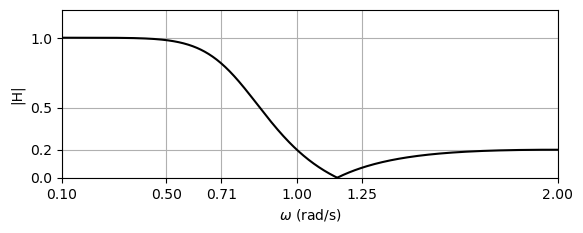

In [30]:
jj = complex(0,1)

Hs = .2
ws = 1
#Hp = .972
#wp = .71

""" Compute a and b """
n = 3
eps = sqrt(Hs**2/(1-Hs**2))
print('eps = ',eps)
alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ',alpha)
a = 0.5*(alpha**(1/n)-alpha**(-1/n))
b = 0.5*(alpha**(1/n) + alpha**(-1/n))
print('a = ',a,' b= ',b)

""" Pole at -180 deg """
p0 = a
d0 = [1,1/a]

""" Pole at -60 deg from -180 """
theta = np.deg2rad(60)
p1 = a*cos(theta) + jj*b*sin(theta)
q1 = 1/p1
d1 = [1,2*q1.real,(q1.real**2 + q1.imag**2)]

den = np.convolve(d0,d1)

""" zeros """
omega1 = 1/cos(1*np.pi/(2*3))
num = [0,1,0,omega1**2]

""" constant """
K = den[3]/num[3]
num = [0,K,0,K*omega1**2]

""" Bode plot """
w = np.linspace(.01,10,1000)
system = sig.lti(num,den)
w,Hmag,Hphase = sig.bode(system,n=1000)

plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
plt.axis([.1, 2, 0, 1.2])
plt.xticks([.1, .5, .71, 1, 1.25, 2])
plt.yticks([0, 0.2, .5, 1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_77528\4127987927.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


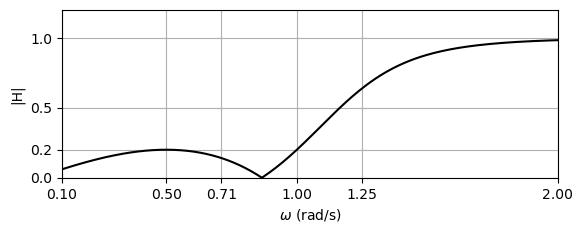

In [34]:
""" Switch to High pass """

#numh = [K*omega1**2,0,K,0]
#denh = [den[3],den[2],den[1],1]

numh = num[::-1]
denh = den[::-1]

w = np.linspace(.01,10,1000)
system = sig.lti(numh,denh)
w,Hmag,Hphase = sig.bode(system,n=1000)

plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
plt.axis([.1, 2, 0, 1.2])
plt.xticks([.1, .5, .71, 1, 1.25, 2])
plt.yticks([0, 0.2, .5, 1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_77528\3789279861.py:15: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


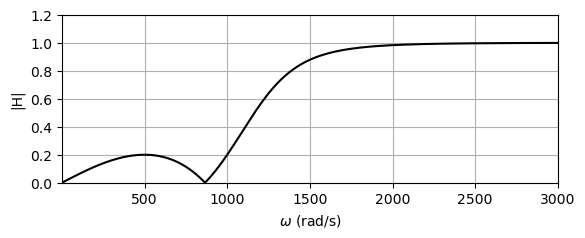

In [46]:
""" Scale to 1000 """

a = 1000
nums = [numh[0],a*numh[1],(a**2)*numh[2],(a**3)*numh[3]]
dens = [denh[0],a*denh[1],(a**2)*denh[2],(a**3)*denh[3]]

w = np.linspace(.01,10,1000)
system = sig.lti(nums,dens)
w,Hmag,Hphase = sig.bode(system,n=1000)

plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
plt.axis([.1, 3000, 0, 1.2])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()